In [42]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as cst

-3 * π * c^2 * Γ / (ω0^2 * (ω0^2 - ωL^2))

In [ ]:
# Transition parameters from Tim Höhn's PhD thesis
# Format: f0_THz = transition frequency, gamma_MHz = linewidth/decay rate
transitions_1S0 = [
    {"name": "(6s6p) 3P1", "f0_THz": 539.386800, "gamma_MHz": 0.183, "J": 1},
    {"name": "(6s6p) 1P1", "f0_THz": 751.526389, "gamma_MHz": 29.127, "J": 1},
    {"name": "(7/2,5/2) J=1", "f0_THz": 865.111516, "gamma_MHz": 11.052, "J": 1},
]
offset_1S0 = -0.8e-4  # Global offset in Hz / (W/cm^2)

transitions_3P0 = [
    {"name": "(6s5d) 3D1", "f0_THz": 215.870446, "gamma_MHz": 0.308, "J": 1},
    {"name": "(6s7s) 3S1", "f0_THz": 461.867846, "gamma_MHz": 1.516, "J": 1},
    {"name": "(6s6d) 3D1", "f0_THz": 675.141040, "gamma_MHz": 4.081, "J": 1},
    {"name": "(6s8s) 3S1", "f0_THz": 729.293151, "gamma_MHz": 0.625, "J": 1},
    {"name": "Empirical J=1", "f0_THz": 797.204099, "gamma_MHz": 23.567, "J": 1}, # 22.889 old gamma
]
offset_3P0 = 0.0  # Hz / (W/cm^2)

transitions_3P1 = [
    {"name": "(6s2) 1S0", "f0_THz": -539.386800, "gamma_MHz": 0.183, "J": 0},
    {"name": "(6s5d) 3D1", "f0_THz": 194.778008, "gamma_MHz": 0.170, "J": 1},
    {"name": "(6s5d) 3D2", "f0_THz": 202.657933, "gamma_MHz": 0.280, "J": 2},
    {"name": "(6s7s) 3S1", "f0_THz": 440.775408, "gamma_MHz": 3.954, "J": 1},
    {"name": "(6s6d) 3D1", "f0_THz": 654.048602, "gamma_MHz": 2.783, "J": 1},
    {"name": "(6s6d) 3D2", "f0_THz": 654.927593, "gamma_MHz": 5.215, "J": 2},
    {"name": "(6s8s) 3S1", "f0_THz": 708.200713, "gamma_MHz": 1.718, "J": 1},
    {"name": "Empirical J=1", "f0_THz": 778.975785, "gamma_MHz": 22.313, "J": 1},
    {"name": "Empirical J=2", "f0_THz": 778.975785, "gamma_MHz": 36.687, "J": 2},
]
offset_3P1 = 0.0 # Hz / (W/cm^2)

# Test model with just a single transition
transitions_1P1 = [
    {"name": "(6s2) 1S)", "f0_THz": -751.5274711, "gamma_MHz": 29.13, "J": 0}
]
offset_1P1 = 0.0 # Hz / (W/cm^2)

# computes scalar line shift at given frequency
def calc_light_shift(omega0, Gamma, omegaL):
    return - 3 * np.pi * cst.c**2 * Gamma / (omega0**2 * (omega0**2 - omegaL**2))

# returns light shift / intensity in SI units
def U_over_I_SI(f_THz, transitions, offset=0.0):
    omegaL = 2 * np.pi * f_THz * 1e12
    #omegaL = 2 * np.pi * cst.c / (wavelength_nm * 1e-9)
    U_I = 0.0
    for transition in transitions:
        omega0 = 2 * np.pi * transition["f0_THz"] * 1e12
        Gamma = 2*np.pi * transition["gamma_MHz"] * 1e6
        U_I += calc_light_shift(omega0, Gamma, omegaL)

    # offset is in Hz / (W/cm^2), so we need to convert it to J/(W/m^2)
    return U_I + offset*cst.h

#wavelengths_nm = np.linspace(400, 1000, 1000)

'''
def make_freq_arrays_THz(all_transitions, f_min, f_max, density, delta):
    trans_freqs = [trans["f0_THz"] for trans in all_transitions]

    assert f_max > f_min

    intervals = []
    lo = f_min
    for f0 in sorted(trans_freqs):
        hi = f0 - delta
        if hi > lo:
            intervals.append((lo, hi))
        lo = f0 + delta
    if lo < f_max:
        intervals.append((lo, f_max))

    freqs_THz = [
        np.linspace(start, end, int(density*(end-start)))
        for start, end in intervals
    ]

    return freqs_THz


f_min = 375 # THz ~ 800 nm
f_max = 750 # THz ~ 400 nm
density = 1000 / (f_max-f_min) # points / THz
delta = 0.1 # THz margin around each resonance

freqs_THz = make_freq_arrays_THz(transitions_1S0+transitions_3P0, f_min, f_max, density, delta)

wavelengths_nm = [
    cst.c / (freq*1e12) * 1e9 for freq in freqs_THz
]

U_I_1S0_SI = [
    (1e4/cst.h) * U_over_I_SI(freq, transitions_1S0, offset_1S0) for freq in freqs_THz
]

U_I_3P0_SI = [
    (1e4/cst.h) * U_over_I_SI(freq, transitions_3P0, offset_3P0) for freq in freqs_THz
]


# Plotting


factor = 5.5
for i in range(len(U_I_1S0_SI)):
    wavelength = wavelengths_nm[i]
    if i == 0:
        plt.plot(wavelength, U_I_1S0_SI[i], c="blue", label="$^1 S_0$")
        continue
    plt.plot(wavelength, U_I_1S0_SI[i], c="blue")


for i in range(len(U_I_3P0_SI)):
    wavelength = wavelengths_nm[i]
    if i == 0:
        plt.plot(wavelength, U_I_3P0_SI[i], c="red", label="$^3 P_0$")
        continue
    plt.plot(wavelength, U_I_3P0_SI[i], c="red")




plt.xlim(420, 800)
plt.ylim(-30, 10)
#plt.ylim(-0.01e-34, 0.01e-34)
plt.legend()
plt.ylabel("$V_{ac}/I$ [SI]")
plt.xlabel("Wavelength [nm]")
plt.show()
'''

'\ndef make_freq_arrays_THz(all_transitions, f_min, f_max, density, delta):\n    trans_freqs = [trans["f0_THz"] for trans in all_transitions]\n\n    assert f_max > f_min\n\n    intervals = []\n    lo = f_min\n    for f0 in sorted(trans_freqs):\n        hi = f0 - delta\n        if hi > lo:\n            intervals.append((lo, hi))\n        lo = f0 + delta\n    if lo < f_max:\n        intervals.append((lo, f_max))\n\n    freqs_THz = [\n        np.linspace(start, end, int(density*(end-start)))\n        for start, end in intervals\n    ]\n\n    return freqs_THz\n\n\nf_min = 375 # THz ~ 800 nm\nf_max = 750 # THz ~ 400 nm\ndensity = 1000 / (f_max-f_min) # points / THz\ndelta = 0.1 # THz margin around each resonance\n\nfreqs_THz = make_freq_arrays_THz(transitions_1S0+transitions_3P0, f_min, f_max, density, delta)\n\nwavelengths_nm = [\n    cst.c / (freq*1e12) * 1e9 for freq in freqs_THz\n]\n\nU_I_1S0_SI = [\n    (1e4/cst.h) * U_over_I_SI(freq, transitions_1S0, offset_1S0) for freq in freqs_THz\

In [182]:
def make_freq_array_THz(all_transitions, f_min, f_max, density, delta):
    trans_freqs = [trans["f0_THz"] for trans in all_transitions]

    assert f_max > f_min

    intervals = []
    lo = f_min
    for f0 in sorted(trans_freqs):
        if f0<0.: continue # negative transitions frequencies to levels below, we don't plot negative freqs.
        hi = f0 - delta
        if hi > lo:
            intervals.append((lo, hi))
        lo = f0 + delta
    if lo < f_max:
        intervals.append((lo, f_max))

    freqs_THz = [
        np.linspace(start, end, int(density*(end-start)))
        for start, end in intervals
    ]

    intervals_idx = []
    start_idx, end_idx = 0, 0
    for i in range(len(intervals)):
        start_idx = end_idx
        end_idx = len(freqs_THz[i]) + start_idx
        intervals_idx.append((start_idx, end_idx))


    return np.concatenate(freqs_THz), intervals_idx

# avoid the transitions
# assumes frequency array is given in ascending order
def plot_lightshift(freq_THz, U_I, interval_idx, figax = None, label = None, c="gray", units="SI", xvar="wavelength"):
    if figax is None:
        fig, ax = plt.subplots()
    else:
        fig, ax = figax

    factor = (1e4/cst.h) if units=="hHz" else 1

    # wavelength (nm) and x axis selection
    wavelength_nm = cst.c / (freq_THz*1e12) * 1e9
    X = wavelength_nm if xvar == "wavelength" else freq_THz

    show_label = True
    for start_idx, end_idx in interval_idx:
        X_seg = X[start_idx:end_idx]
        Y_seg = factor * U_I[start_idx:end_idx]

        # Ensure we plot with X increasing to avoid connecting segments wrongly
        if X_seg.size == 0:
            continue
        sort_idx = np.argsort(X_seg)
        X_seg_s = X_seg[sort_idx]
        Y_seg_s = Y_seg[sort_idx]

        if show_label:
            ax.plot(X_seg_s, Y_seg_s, c=c, label=label)
            show_label = False
        else:
            ax.plot(X_seg_s, Y_seg_s, c=c)

    return fig, ax, wavelength_nm

[(0, 2891), (2891, 3800), (3800, 5394), (5394, 6028), (6028, 6287), (6287, 6822), (6822, 7618)]


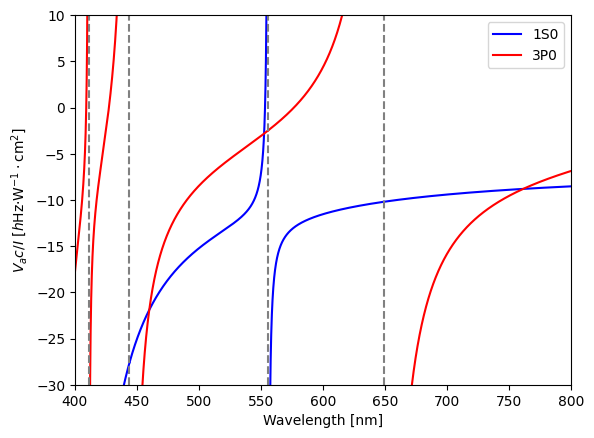

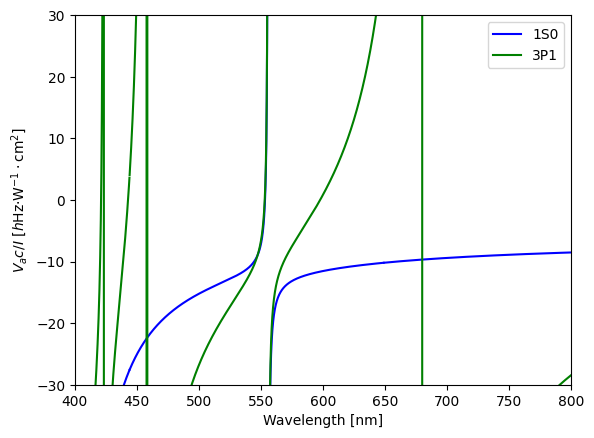

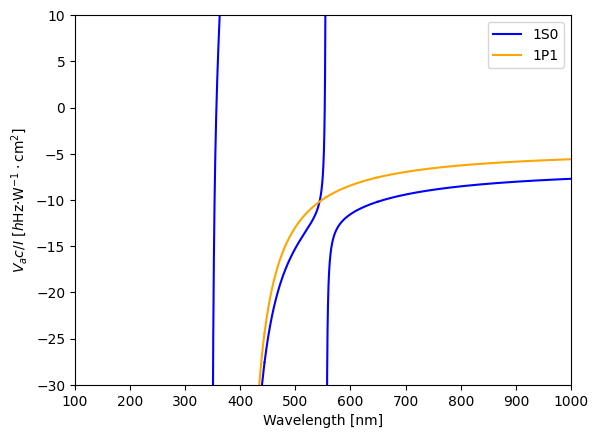

In [185]:
freq_THz, plt_intervals = make_freq_array_THz(transitions_1S0+transitions_3P0, f_min, f_max, density, delta)
U_1S0 = U_over_I_SI(freq_THz, transitions_1S0, offset_1S0)
U_3P0 = U_over_I_SI(freq_THz, transitions_3P0, offset_3P0)
U_3P1 = U_over_I_SI(freq_THz, transitions_3P1, offset_3P0)
U_1P1 = U_over_I_SI(freq_THz, transitions_1P1, offset_1P1)

#plt.plot(freq_THz, U_1S0*(1e4/cst.h), c="b")
#plt.plot(freq_THz, U_3P0*(1e4/cst.h), c="r")
#plt.ylim(-30, 10)

print(plt_intervals)


fig, ax, wavelength_nm = plot_lightshift(freq_THz, U_1S0, interval_idx=plt_intervals, label="1S0", c="b", units="hHz")
plot_lightshift(freq_THz, U_3P0, interval_idx=plt_intervals, label="3P0", c="red", figax=(fig, ax), units="hHz")
#plt.plot(wavelength_nm, (1e4/cst.h)*U_3P0, c="r")

for i in range(len(plt_intervals)):
    ax.axvline(wavelength_nm[plt_intervals[i][0]], c="grey", linestyle="--")


plt.legend()
plt.xlim(400, 800)
plt.ylim(-30, 10)
plt.xlabel("Wavelength [nm]")
plt.ylabel(r"$V_ac/I$ [$h$Hz$\cdot$W$^{-1}\cdot$cm$^{2}$]")
plt.show()




fig, ax, wavelength_nm = plot_lightshift(freq_THz, U_1S0, interval_idx=plt_intervals, label="1S0", c="b", units="hHz")
plot_lightshift(freq_THz, U_3P1, interval_idx=plt_intervals, label="3P1", c="green", figax=(fig, ax), units="hHz")
#plt.plot(wavelength_nm, (1e4/cst.h)*U_3P0, c="r")

plt.legend()
plt.xlim(400, 800)
plt.ylim(-30, 30)
plt.xlabel("Wavelength [nm]")
plt.ylabel(r"$V_ac/I$ [$h$Hz$\cdot$W$^{-1}\cdot$cm$^{2}$]")
plt.show()




fig, ax, wavelength_nm = plot_lightshift(freq_THz, U_1S0, interval_idx=plt_intervals, label="1S0", c="b", units="hHz")
plot_lightshift(freq_THz, U_1P1, interval_idx=plt_intervals, label="1P1", c="orange", figax=(fig, ax), units="hHz")
#plt.plot(wavelength_nm, (1e4/cst.h)*U_3P0, c="r")

plt.legend()
plt.xlim(100, 1000)
plt.ylim(-30, 10)
plt.xlabel("Wavelength [nm]")
plt.ylabel(r"$V_ac/I$ [$h$Hz$\cdot$W$^{-1}\cdot$cm$^{2}$]")
plt.show()




        


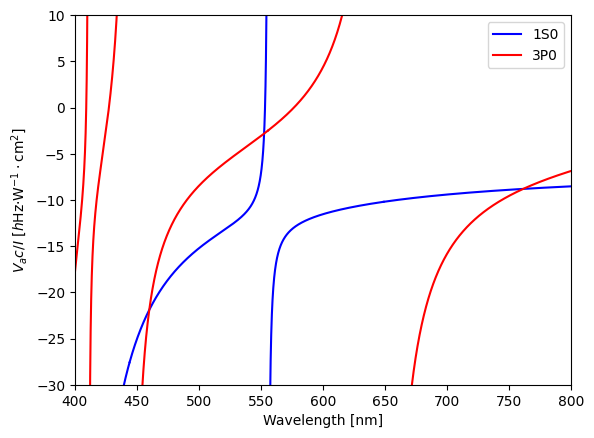

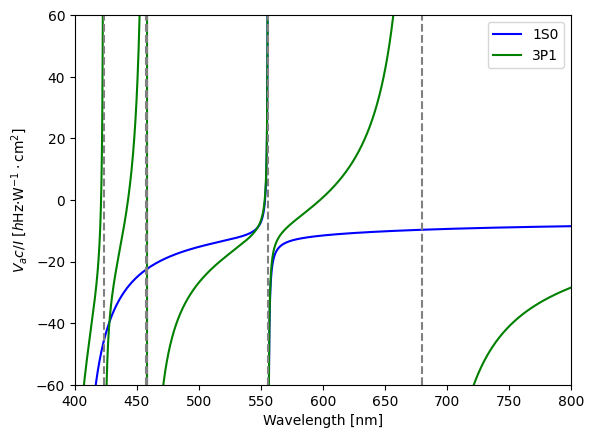

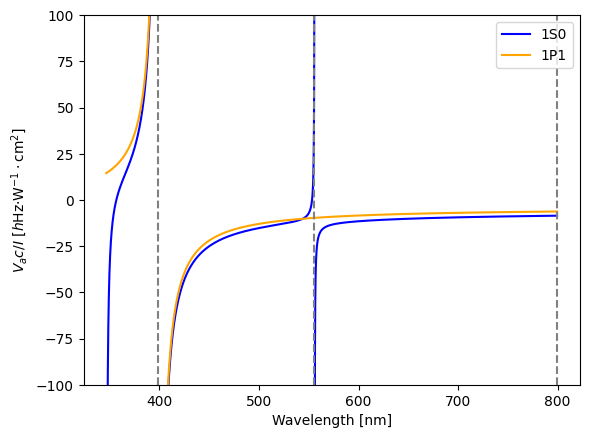

215.97044599999998 194.878008 375.0


In [193]:
f_min = 375 # THz
f_max = 800 # THz
density = 5000 / (f_max - f_min)
delta = 0.1 # THz margin around resonances

freq3P0_THz, intervals_3P0 = make_freq_array_THz(transitions_1S0+transitions_3P0, f_min, f_max, density, delta)
U_1S0_1 = U_over_I_SI(freq3P0_THz, transitions_1S0, offset_1S0)
U_3P0 = U_over_I_SI(freq3P0_THz, transitions_3P0, offset_3P0)

fig, ax, wavelength_nm = plot_lightshift(freq3P0_THz, U_1S0_1, interval_idx=intervals_3P0, label="1S0", c="b", units="hHz")
plot_lightshift(freq3P0_THz, U_3P0, interval_idx=intervals_3P0, label="3P0", c="red", figax=(fig, ax), units="hHz")

plt.legend()
plt.xlim(400, 800)
plt.ylim(-30, 10)
plt.xlabel("Wavelength [nm]")
plt.ylabel(r"$V_ac/I$ [$h$Hz$\cdot$W$^{-1}\cdot$cm$^{2}$]")
plt.show()


freq3P1_THz, intervals_3P1 = make_freq_array_THz(transitions_1S0+transitions_3P1, f_min, f_max, density, delta)
U_1S0_2 = U_over_I_SI(freq3P1_THz, transitions_1S0, offset_1S0)
U_3P1 = U_over_I_SI(freq3P1_THz, transitions_3P1, offset_3P1)

fig, ax, wavelength_nm = plot_lightshift(freq3P1_THz, U_1S0_2, interval_idx=intervals_3P1, label="1S0", c="b", units="hHz")
plot_lightshift(freq3P1_THz, U_3P1, interval_idx=intervals_3P1, label="3P1", c="green", figax=(fig, ax), units="hHz")

for i in range(len(intervals_3P1)):
    ax.axvline(wavelength_nm[intervals_3P1[i][0]], c="grey", linestyle="--")

plt.legend()
plt.xlim(400, 800)
plt.ylim(-60, 60)
plt.xlabel("Wavelength [nm]")
plt.ylabel(r"$V_ac/I$ [$h$Hz$\cdot$W$^{-1}\cdot$cm$^{2}$]")
plt.show()

freq1P1_THz, intervals_1P1 = make_freq_array_THz(transitions_1S0+transitions_1P1, f_min, f_max, density, delta)
U_1S0_3 = U_over_I_SI(freq1P1_THz, transitions_1S0, offset_1S0)
U_1P1 = U_over_I_SI(freq1P1_THz, transitions_1P1, offset_1P1)

fig, ax, wavelength_nm = plot_lightshift(freq1P1_THz, U_1S0_3, interval_idx=intervals_1P1, label="1S0", c="b", units="hHz")
plot_lightshift(freq1P1_THz, U_1P1, interval_idx=intervals_1P1, label="1P1", c="orange", figax=(fig, ax), units="hHz")

for i in range(len(intervals_1P1)):
    ax.axvline(wavelength_nm[intervals_1P1[i][0]], c="grey", linestyle="--")

plt.legend()
#plt.xlim(100, 1000)
plt.ylim(-100, 100)
#plt.ylim(-30, 10)
plt.xlabel("Wavelength [nm]")
plt.ylabel(r"$V_ac/I$ [$h$Hz$\cdot$W$^{-1}\cdot$cm$^{2}$]")
plt.show()


print(min(freq3P0_THz), min(freq3P1_THz), min(freq1P1_THz))


[(0, np.int64(175)), (np.int64(176), np.int64(438)), (np.int64(439), np.int64(944)), (np.int64(945), 1000)]


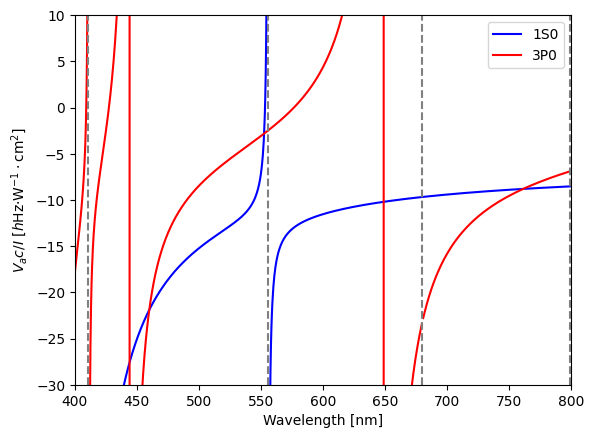

In [ ]:
def find_continuous_intervals(freqs, transitions, delta=0.1):
    """
    Given a (not necessarily strictly) ascending frequency array `freqs` (THz)
    and `transitions` (iterable of dicts with 'f0_THz' or numeric freqs),
    return a list of (start_idx, end_idx) tuples for intervals in `freqs`
    where the lightshift is continuous (i.e. excluding +/- delta around each resonance).
    end_idx is exclusive, as in Python slicing.
    """
    # extract transition frequencies
    f0s = []
    for t in transitions:
        try:
            f0s.append(float(t["f0_THz"]))
        except Exception:
            # if transition is given as a bare number
            try:
                f0s.append(float(t))
            except Exception:
                continue

    if len(freqs) == 0:
        return []

    n = len(freqs)
    # build excluded index intervals around each resonance
    excl = []
    for f0 in sorted(set(f0s)):
        lo = f0 - delta
        hi = f0 + delta
        lo_idx = np.searchsorted(freqs, lo, side="left")
        hi_idx = np.searchsorted(freqs, hi, side="right")
        lo_idx = max(0, min(n, lo_idx))
        hi_idx = max(0, min(n, hi_idx))
        if lo_idx < hi_idx:
            excl.append((lo_idx, hi_idx))

    # merge overlapping/adjacent excluded intervals
    if not excl:
        return [(0, n)]
    excl.sort(key=lambda x: x[0])
    merged = [excl[0]]
    for s, e in excl[1:]:
        ms, me = merged[-1]
        if s <= me:  # overlap or adjacent
            merged[-1] = (ms, max(me, e))
        else:
            merged.append((s, e))

    # build continuous intervals as gaps between merged excluded intervals
    cont = []
    start = 0
    for s, e in merged:
        if s > start:
            cont.append((start, s))
        start = e
    if start < n:
        cont.append((start, n))

    return cont

need to make sure it catches all the resonances, makes an ugly plot and will make finding magic wavelengths difficult

## Compute magic wavelengths from polarisability model

In [190]:
def find_intersections(U_1, U_2, intervals_idx):
    """
    Find indices where two light shift curves intersect, accounting for discontinuities.
    
    Parameters:
    U_1, U_2: numpy arrays of light shift values
    freq_THz: frequency array
    intervals_idx: list of (start, end) tuples for continuous regions
    
    Returns:
    List of tuples (index, frequency_THz) where curves intersect
    """
    intersections = []
    
    for start_idx, end_idx in intervals_idx:
        # Only look within continuous intervals
        U1_segment = U_1[start_idx:end_idx]
        U2_segment = U_2[start_idx:end_idx]
        diff = U1_segment - U2_segment
        
        # Find sign changes
        sign_changes = np.where(np.diff(np.sign(diff)))[0]
        
        for change_idx in sign_changes:
            actual_idx = start_idx + change_idx
            intersections.append(actual_idx)
    
    return intersections


idx_1S0_3P0 = find_intersections(U_1S0_1, U_3P0, intervals_3P0)
print("1S0 -> 3P0 magic wavelengths")
for idx in idx_1S0_3P0:
    f = freq3P0_THz[idx]
    print(f"Magic frequency: {f} THz, {cst.c/(f*1e12) * 1e9} nm")

print()

idx_1S0_3P1 = find_intersections(U_1S0_2, U_3P1, intervals_3P1)
print("1S0 -> 3P1 magic wavelengths")
for idx in idx_1S0_3P1:
    f = freq3P1_THz[idx]
    print(f"Magic frequency: {f} THz, {cst.c/(f*1e12) * 1e9} nm")

print()

idx_1S0_1P1 = find_intersections(U_1S0_3, U_1P1, intervals_1P1)
print("1S0 -> 1P1 magic wavelengths")
for idx in idx_1S0_1P1:
    f = freq1P1_THz[idx]
    print(f"Magic frequency: {f} THz, {cst.c/(f*1e12) * 1e9} nm")


1S0 -> 3P0 magic wavelengths
Magic frequency: 393.6419922283737 THz, 761.5865784615623 nm
Magic frequency: 542.4650789704959 THz, 552.648400094166 nm
Magic frequency: 651.7253703452604 THz, 459.99813977040793 nm
Magic frequency: 728.6817565829383 THz, 411.4175431066631 nm

1S0 -> 3P1 magic wavelengths
Magic frequency: 197.81191193258428 THz, 1515.5429977451074 nm
Magic frequency: 283.0274456518942 THz, 1059.234581683381 nm
Magic frequency: 547.6565643063198 THz, 547.4095948794611 nm
Magic frequency: 654.2617671666667 THz, 458.21485075962096 nm
Magic frequency: 700.6892179117175 THz, 427.85367654647143 nm

1S0 -> 1P1 magic wavelengths
Magic frequency: 551.2234225048154 THz, 543.8674152083606 nm


# Tensor polarizability

In [194]:
e = -3

print(np.sign(e))

-1


In [ ]:
# Quantum numbers for J manifolds
states = {
    "1S0": {"J": 0, "L": 0, "S": 0},
    "3P0": {"J": 0, "L": 1, "S": 1},
    "3P1": {"J": 1, "L": 1, "S": 1}
}

# transitions freq = 1/hbar (E_J' - E_J)
# it is positive if E_J' > E_J
# is it negative if E_J' < E_J
def _f(J, Jp, transition_freq):
    if np.sign(transition_freq) == 1:
        return (2*Jp+1)/(2*J+1)
    else:
        return (2*J+1)/(2*Jp+1)

def V_I_scalar_SI(freq_THz, trans, offset = 0.0, state="1S0"):
    J = states[state]["J"]
    V_I = 0.0
    for tr in trans:
        deg_factor = 